# BGC-Argo: mixed-layer depth & summary (Stage 2)

PAB turns each BGC-Argo profile into one **mixed-layer summary** record following the Bisson et al. (2019) recipe: compute the MLD (de Boyer Montégut density threshold), de-spike `BBP700`, drop log-IQR outliers, and average within the mixed layer.

The core methods (`pab.argo.mld`, `pab.argo.summary`) work on plain arrays, so the first sections run **fully offline** with a synthetic profile. A final, optional section pulls a **live** profile from argopy. See `docs/argo_ingestion.rst` for the method note.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

## 1. Mixed-layer depth (de Boyer Montégut)

The MLD is the shallowest depth below 10 m where the potential density `SIG0` exceeds its 10 m value by 0.03 kg m⁻³. The pure-NumPy `mixed_layer_depth` takes pressure + density directly.

In [2]:
from pab.argo import mld

pres = np.array([5., 10., 20., 30., 40., 50.])
sig0 = np.array([25.00, 25.00, 25.005, 25.01, 25.05, 25.10])
print('MLD =', mld.mixed_layer_depth(pres, sig0), 'm')
print('method:', mld.MLD_METHOD)

MLD = 40.0 m
method: deBoyerMontegut_0.03


In practice `SIG0` comes from in-situ salinity/temperature via TEOS-10 (`gsw`), exactly as argopy's `teos10` accessor does. `mixed_layer_depth_from_ts` chains the two steps.

In [3]:
pres = np.linspace(0, 200, 41)
psal = np.full_like(pres, 35.0)
temp = np.where(pres < 50, 20.0, 12.0)   # thermocline near 50 m
lon, lat = -30.0, 45.0
mld_val = mld.mixed_layer_depth_from_ts(pres, psal, temp, lon, lat)
print(f'MLD = {mld_val:.1f} m')

MLD = 50.0 m


## 2. De-spiking `BBP700`

A 3-point moving median removes single-sample bubble spikes while preserving real structure.

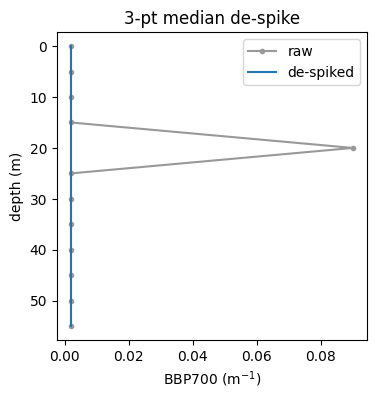

In [4]:
from pab.argo import summary

z = np.arange(0, 60, 5.0)
bbp = np.full_like(z, 2.0e-3)
bbp[4] = 9.0e-2          # injected bubble spike
bbp_ds = summary.despike(bbp)

fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(bbp, z, '.-', color='0.6', label='raw')
ax.plot(bbp_ds, z, '-', color='C0', label='de-spiked')
ax.invert_yaxis(); ax.set_xlabel('BBP700 (m$^{-1}$)')
ax.set_ylabel('depth (m)'); ax.legend(); ax.set_title('3-pt median de-spike')
plt.show()

## 3. Whole-profile summary

`summarize_profile` ties it together: MLD, de-spiked + IQR-filtered mixed-layer `BBP700`, mixed-layer `CHLA`, and mean `PSAL`/`TEMP`.

In [5]:
pres = np.array([5., 10., 20., 30., 40., 50.])
sig0 = np.array([25.00, 25.00, 25.005, 25.01, 25.05, 25.10])
bbp  = np.array([2e-3, 2e-3, 9e-2, 2e-3, 2e-3, 1e-3])  # spike inside MLD
chla = np.array([0.5, 0.5, 0.5, 0.5, 0.2, 0.1])

out = summary.summarize_profile(
    pres, bbp700=bbp, chla=chla, sig0=sig0,
    despike_bbp=True, iqr_filter=False)
out

{'mld': 40.0,
 'mld_method': 'deBoyerMontegut_0.03',
 'bbp700': 0.002,
 'bbp700_std': 0.0,
 'chla': 0.44000000000000006,
 'chla_std': 0.12,
 'psal': nan,
 'temp': nan,
 'n_points': 5}

## 4. Persist to the database

`persist_summary` writes the `floats` / `profiles` / `mld_summary` rows (idempotent), stamping `pab_version` + `created`.

In [6]:
from pab.db import Store

store = Store.open(':memory:')
pid = summary.persist_summary(
    store, wmo=6903823, cycle=387, summary=out,
    latitude=lat, longitude=lon, time='2024-05-01T00:00:00')
rows = store.query('SELECT * FROM mld_summary WHERE profile_id = ?', (pid,))
store.close()
rows

[{'profile_id': 1,
  'mld': 40.0,
  'mld_method': 'deBoyerMontegut_0.03',
  'bbp700': 0.002,
  'bbp700_std': 0.0,
  'chla': 0.44000000000000006,
  'chla_std': 0.12,
  'psal': None,
  'temp': None,
  'n_points': 5,
  'created': '2026-06-20T12:16:04.513661+00:00',
  'pab_version': '0.0.dev0'}]

## 5. Q&A plot

The `qa` module renders the diagnostic profile (de-spike overlay + MLD line).

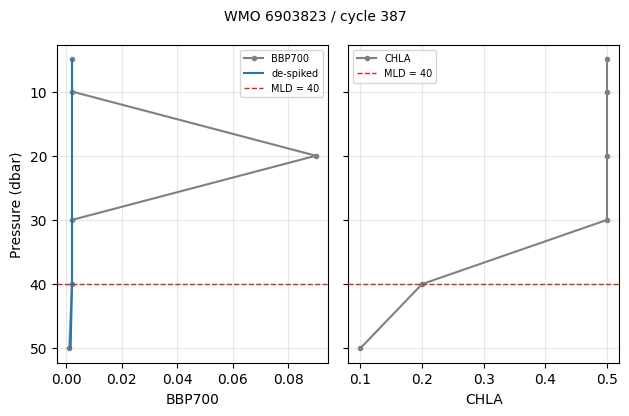

In [7]:
from pab.argo import qa

fig = qa.plot_profile(pres, bbp700=bbp, chla=chla, mld=out['mld'],
                      title='WMO 6903823 / cycle 387')
plt.show()

## 6. (Optional) live data from argopy

Set `RUN_LIVE = True` to fetch a real BGC profile from the Ifremer ERDDAP (requires network; may take a minute). This is the path the pipeline uses; it is skipped by default so the notebook runs offline.

In [8]:
RUN_LIVE = False  # flip to True to pull live data

if RUN_LIVE:
    from pab.argo import fetch
    # a small region + time window keeps the request light
    box = [-35, -30, 40, 45, 0, 500, '2024-05-01', '2024-05-08']
    ds = fetch.fetch_region(box)
    ds = fetch.filter_quality(ds)
    for meta, var in fetch.iter_profiles(ds):
        s = summary.summarize_profile(
            var.get('PRES'), bbp700=var.get('BBP700'),
            chla=var.get('CHLA'), psal=var.get('PSAL'),
            temp=var.get('TEMP'),
            lon=meta['longitude'], lat=meta['latitude'])
        print(meta['wmo'], meta['cycle'], 'MLD=%.1f' % s['mld'],
              'bbp=%.2e' % s['bbp700'])
        break
else:
    print('RUN_LIVE is False — skipping the network fetch.')

RUN_LIVE is False — skipping the network fetch.
